# Comparative Evolution of the HBB Gene Across Primates

**Project type:** Comparative sequence bioinformatics / molecular evolution

---

## Project overview

This notebook investigates the **evolutionary conservation of the HBB (beta-globin) gene across selected primates** using the HBB sequence records supplied for this project.

The workflow is intentionally transparent: the FASTA records are embedded directly in the notebook, each sequence is read and checked separately, comparable coding sequences are extracted, and nucleotide- and protein-level conservation are quantified.

> **The aim is not to make a large or complicated pipeline. The aim is to show a clear biological question, appropriate computational analysis, quality control, reproducibility, and careful biological interpretation.**


## Biological question

> **How conserved is the HBB gene across selected primates, and what do patterns of nucleotide and amino-acid conservation suggest about evolutionary constraint on this functionally important hemoglobin gene?**

### Working hypothesis

Because HBB encodes an essential component of hemoglobin, we expect its coding sequence and encoded protein to be relatively conserved across primates. We also expect more closely related primates to show greater sequence similarity than more distantly related primates.

**Important:** sequence conservation is consistent with evolutionary constraint, but this project does **not** by itself prove a particular selection mechanism.


## What this notebook does

**Input → QC → CDS extraction → nucleotide comparison → conservation profile → translation → protein comparison → synonymous/non-synonymous analysis → biological interpretation**

### Main outputs

1. Sequence-level quality-control table
2. Comparable HBB CDS lengths and QC checks
3. Nucleotide identity relative to human HBB
4. A position-by-position HBB nucleotide conservation plot
5. Protein identity relative to human HBB
6. Synonymous versus non-synonymous coding differences
7. A final biological interpretation and limitations

### Reproducibility note

The five supplied FASTA records are embedded **individually** in the notebook. A reader does not need to download separate sequence files just to reproduce the core analysis.


# 3. Dataset

The project contains five supplied HBB records:

| Species | Role in analysis |
|---|---|
| Human | Reference sequence |
| Gorilla | Curated CDS comparison |
| Orangutan | Curated CDS comparison |
| Rhesus macaque | Curated CDS comparison |
| Chimpanzee | QC only; partial genomic record |

Each FASTA record is embedded in its **own separate code cell** so a reviewer can inspect the original sequence and header.



# 4.1 Human — original FASTA record

This is the **original FASTA record supplied for the project**.




In [1]:
# Original FASTA record — Human
human_fasta = r'''>CR536530.1 Homo sapiens full open reading frame cDNA clone RZPDo834D0222D for gene HBB, hemoglobin, beta; complete cds, incl. stopcodon
ATGGTGCACCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAG
TTGGTGGTGAGGCCCTGGGCAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGAGTCCTTTGG
GGATCTGTCCACTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAAGTGCTCGGT
GCCTTTAGTGATGGCCTGGCTCACCTGGACAACCTCAAGGGCACCTTTGCCACACTGAGTGAGCTGCACT
GTGACAAGCTGCACGTGGATCCTGAGAACTTCAGGCTCCTGGGCAACGTGCTGGTCTGTGTGCTGGCCCA
TCACTTTGGCAAAGAATTCACCCCACCAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGGTGTGGCTAAT
GCCCTGGCCCACAAGTATCACTAA'''


In [2]:
from io import StringIO
from Bio import SeqIO

human_record = SeqIO.read(StringIO(human_fasta), "fasta")

print("✓ Human HBB sequence successfully read.")
print("  Accession:", human_record.id)
print("  Sequence length:", len(human_record.seq), "nt")


✓ Human HBB sequence successfully read.
  Accession: CR536530.1
  Sequence length: 444 nt


# 4.2 Chimpanzee — original FASTA record

This is the **original FASTA record supplied for the project**.




In [3]:
# Original FASTA record — Chimpanzee
chimpanzee_fasta = r'''>FJ788196.1 Pan troglodytes ellioti isolate 127 beta globin (hbb) gene, exons 1 and 2 and partial cds
CCAAATGAGGAGAAGATATGCTTAGAACTGAGGTAGAGTTTTCATCCATTCTGTCCTGTAAGTATTTTGC
ATATTCTGGAGACACAGGAAGAGATCCATCTACACATCCCAAAGCTGAATTATGGTAGACAAAACTCTTC
CACTTTTAGTGCATCAATTTCTTATTTGTGTAATAAGAAAATTGGGAAAACGATCTTCAATATGCTTACC
AAGCTGTGATTCCAAATATTACGTAAACACACTTGCAAAGGAGGATGTTTTTAGTAGCAATTTGTACTGA
TGGTGTGGGGCCAAGAGATATATCTTAGAGGGAGGGCTGAGGGTTTGAAGTCCAACTCCTAAGCCAGTGC
CAGAAGAGCCAAGGACAGGTATGGCTGTCATCACTTAGACCTCACCCTGTGGAGCCACACCCTAGGGTTG
GCCAATCTACTCCCAGGAGCAGGGAGGGCAGGAGCCAGGGCTGGGCATAAAAGTCAGGGCAGAGCCATCT
ATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACCATGGTGCACCTGA
CTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAGTTGGTGGTGAGGC
CCTGGGCAGGTTGGTATCAAGGTTACAAGACAGGCTTAAGGAGACCAGTAGAAACTGGGCATGTGGAGAC
AGAGAAGACTCTTGGGTTTCTGATAGGCACTGACTCTCTCTGCCTATTGGGCTATTTTCCCACCCTTAGG
CTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGAGTCCTTTGGGGATCTGTCCACTCCTGATGCTG
TTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAAGTGCTCGGTGCCTTTAGTGATGGCCTGGCTCA
CCTGGACAACCTCAAGGGCACCTTTGCCACACTGAGTGAGCTGCACTGTGACAAGCTGCACGTGGATCCT
GAGAACTTCAGGGTGAGTCTATGGGACCCTTG'''


In [4]:
from io import StringIO
from Bio import SeqIO

chimpanzee_record = SeqIO.read(StringIO(chimpanzee_fasta), "fasta")

print("✓ Chimpanzee HBB sequence successfully read.")
print("  Accession:", chimpanzee_record.id)
print("  Sequence length:", len(chimpanzee_record.seq), "nt")


✓ Chimpanzee HBB sequence successfully read.
  Accession: FJ788196.1
  Sequence length: 1012 nt


# 4.3 Gorilla — original FASTA record

This is the **original FASTA record supplied for the project**.



In [5]:
# Original FASTA record — Gorilla
gorilla_fasta = r'''>XM_019036164.3 PREDICTED: Gorilla gorilla gorilla hemoglobin subunit beta (LOC101126932), mRNA
TCTATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACCATGGTGCACC
TGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAGTTGGTGGTGA
GGCCCTGGGCAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGAGTCCTTTGGGGATCTGTCC
ACTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAAGTGCTCGGTGCCTTTAGTG
ATGGCCTGGCTCACCTGGACAACCTCAAGGGCACCTTTGCCACACTGAGTGAGCTGCACTGTGACAAGCT
GCACGTGGATCCTGAGAACTTCAAGCTCCTGGGCAATGTGCTGGTCTGTGTGCTGGCCCATCACTTTGGC
AAAGAATTCACCCCACCAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGGTGTGGCTAATGCCCTGGCCC
ACAAGTATCACTAAGCTCGCTTTCTTGCTGTCCAATTTCTATTAAAGGTTCCTTTGTTCCCTAAGTCCAA
CCACTAAACTGGGGGATATTATGAAGGGCCTTGAGCATCTGGATTCTGCCTAATAAAAAACATTTATTTT
CATGGCAA'''


In [6]:
from io import StringIO
from Bio import SeqIO

gorilla_record = SeqIO.read(StringIO(gorilla_fasta), "fasta")

print("✓ Gorilla HBB sequence successfully read.")
print("  Accession:", gorilla_record.id)
print("  Sequence length:", len(gorilla_record.seq), "nt")


✓ Gorilla HBB sequence successfully read.
  Accession: XM_019036164.3
  Sequence length: 638 nt


# 4.4 Orangutan — original FASTA record

This is the **original FASTA record supplied for the project**.




In [7]:
# Original FASTA record — Orangutan
orangutan_fasta = r'''>XM_002822127.6 PREDICTED: Pongo abelii hemoglobin subunit beta (HBB), mRNA
TAAAAGTTAGGGCAGAGCCATCTATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCA
AACAGACACCATGGTGCACCTGACTCCTGAGGAGAAGTCTGCTGTTACTGCCCTGTGGGGCAAGGTGAAC
GTGGATGAAGTTGGTGGTGAGGCCCTGGGCAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTG
AGTCCTTTGGGGATCTGTCCACTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAA
AGTGCTCGGTGCCTTTAGTGATGGCCTGGCTCACCTGGACAACCTCAAGGGCACCTTTGCCAAGCTGAGT
GAGCTGCACTGTGACAAGCTGCACGTGGATCCTGAGAACTTCAGGCTCCTGGGCAATGTGCTGGTCTGTG
TGCTGGCCCATCACTTTGGCAAAGAATTCACCCCGCAAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGG
TGTGGCTAATGCCCTGGCCCACAAGTACCACTAAGCTCGCTTTCTTGCTGTCCAATTTGTATTATAGGTT
CCTTTGTTCCCTAAGTCCAACTACTAAACTGGGGGATATTATGAAGGGCCTTGAGCATCTGGATTCTGCC
TAATAAAAAACATTTATTTTCATTGCAA'''


In [8]:
from io import StringIO
from Bio import SeqIO

orangutan_record = SeqIO.read(StringIO(orangutan_fasta), "fasta")

print("✓ Orangutan HBB sequence successfully read.")
print("  Accession:", orangutan_record.id)
print("  Sequence length:", len(orangutan_record.seq), "nt")


✓ Orangutan HBB sequence successfully read.
  Accession: XM_002822127.6
  Sequence length: 658 nt


# 4.5 Rhesus macaque — original FASTA record

This is the **original FASTA record supplied for the project**.




In [9]:
# Original FASTA record — Rhesus macaque
rhesus_macaque_fasta = r'''>NM_001164428.1 Macaca mulatta hemoglobin subunit beta (HBB), mRNA
ACAGACACCATGGTGCATCTGACTCCTGAGGAGAAGACTGCCGTTACCACCCTGTGGGGCAAGGTGAACG
TGGATGAAGTTGGTGGTGAGGCCCTGGGCAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGA
TTCCTTTGGGGATCTGTCCTCTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAA
GTGCTTGGTGCCTTTAGTGATGGCCTGAATCACCTGGACAACCTCAAGGGCACCTTTGCCCAGCTCAGTG
AGCTGCACTGTGACAAGCTGCATGTGGATCCTGAGAACTTCAAGCTCCTGGGCAACGTGCTGGTGTGTGT
GCTGGCCCATCACTTTGGCAAAGAATTCACCCCGCAAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGGT
GTGGCTAATGCCCTGGCCCACAAGTACCACTAAGCTCACTTTCTTGCTGTC'''


In [10]:
from io import StringIO
from Bio import SeqIO

rhesus_macaque_record = SeqIO.read(StringIO(rhesus_macaque_fasta), "fasta")

print("✓ Rhesus macaque HBB sequence successfully read.")
print("  Accession:", rhesus_macaque_record.id)
print("  Sequence length:", len(rhesus_macaque_record.seq), "nt")


✓ Rhesus macaque HBB sequence successfully read.
  Accession: NM_001164428.1
  Sequence length: 471 nt


# 5. Read all records into a project dataset

The individual FASTA records above remain separate. This cell simply collects the already-read records so the downstream analysis can be concise.


In [11]:
# Build the project record dictionary

records = {
    "Human": human_record,
    "Chimpanzee": chimpanzee_record,
    "Gorilla": gorilla_record,
    "Orangutan": orangutan_record,
    "Rhesus macaque": rhesus_macaque_record,
}

expected_species = ["Human", "Chimpanzee", "Gorilla", "Orangutan", "Rhesus macaque"]
assert list(records.keys()) == expected_species

print("✓ All five supplied HBB records were successfully read.")
print("Records available:", ", ".join(records.keys()))


✓ All five supplied HBB records were successfully read.
Records available: Human, Chimpanzee, Gorilla, Orangutan, Rhesus macaque


# 6. Raw sequence quality control

Before biological comparison, we check:

- accession
- sequence length
- ambiguous nucleotides
- GC percentage
- presence of an HBB start motif

This step prevents us from treating different sequence contexts as though they were identical biological regions.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Bio.Seq import Seq

qc_rows = []

for species, record in records.items():
    seq = str(record.seq).upper()

    qc_rows.append({
        "Species": species,
        "Accession": record.id,
        "Length_nt": len(seq),
        "Ambiguous_bases": sum(base not in "ACGT" for base in seq),
        "GC_percent": round(
            100 * (seq.count("G") + seq.count("C")) / len(seq), 2
        ),
        "HBB_start_motif_position_0based": seq.find("ATGGTGCAC"),
        "Description": record.description,
    })

raw_qc = pd.DataFrame(qc_rows)

print("✓ Raw sequence QC completed for all five supplied records.")
display(raw_qc)


✓ Raw sequence QC completed for all five supplied records.


,Species,Accession,Length_nt,Ambiguous_bases,GC_percent,HBB_start_motif_position_0based,Description
0,Human,CR536530.1,444,0,56.31,0,CR536530.1 Homo sapiens full open reading fram...
1,Chimpanzee,FJ788196.1,1012,0,48.81,547,FJ788196.1 Pan troglodytes ellioti isolate 127...
2,Gorilla,XM_019036164.3,638,0,51.10,60,XM_019036164.3 PREDICTED: Gorilla gorilla gori...
3,Orangutan,XM_002822127.6,658,0,50.76,80,XM_002822127.6 PREDICTED: Pongo abelii hemoglo...
4,Rhesus macaque,NM_001164428.1,471,0,54.99,-1,NM_001164428.1 Macaca mulatta hemoglobin subun...


# 7. Why is chimpanzee handled separately?

The supplied chimpanzee record is annotated as a **genomic HBB record containing exons 1 and 2 and partial CDS**. Its raw length is 1,012 nt, and the HBB start motif occurs at position 547 (0-based).

This is not the same sequence context as the complete/curated CDS records used below.

A professional workflow should **not silently pretend that the entire 1,012-nt genomic record is a complete HBB CDS**.

Therefore:

- chimpanzee remains in the dataset and QC;
- chimpanzee is documented explicitly;
- chimpanzee is excluded from the four-species complete-CDS quantitative comparison;
- the exact annotated chimpanzee CDS coordinates should be retrieved/confirmed before adding it to the same comparison.

This is a methodological choice, not missing data being ignored.

In [13]:
chimp_seq = str(records["Chimpanzee"].seq).upper()

print("Chimpanzee record check")
print("-----------------------")
print("Accession:", records["Chimpanzee"].id)
print("Raw length:", len(chimp_seq), "nt")
print("HBB start motif position:", chimp_seq.find("ATGGTGCAC"))
print("Decision: retained separately because the supplied record is partial/genomic.")


Chimpanzee record check
-----------------------
Accession: FJ788196.1
Raw length: 1012 nt
HBB start motif position: 547
Decision: retained separately because the supplied record is partial/genomic.


# 8. Prepare comparable HBB CDS sequences

For the four curated comparison sequences:

- Human, Gorilla, and Orangutan are searched for the conserved HBB start motif `ATGGTGCAC`.
- Rhesus macaque is searched from the first `ATG` in the supplied transcript-like record.
- The first in-frame stop codon defines the CDS endpoint.

The extracted CDS is then checked for length, reading frame, and stop codons.


In [14]:
# Extract comparable HBB CDS regions without an external aligner

from io import StringIO
from Bio import SeqIO
from Bio.Seq import Seq

# If this cell is run independently after a kernel restart, rebuild `records`
# from the five embedded FASTA strings when those variables are available.
if "records" not in globals():
    fasta_sources = {
        "Human": "human_fasta",
        "Chimpanzee": "chimpanzee_fasta",
        "Gorilla": "gorilla_fasta",
        "Orangutan": "orangutan_fasta",
        "Rhesus macaque": "rhesus_macaque_fasta",
    }

    missing_fasta = [name for name, var in fasta_sources.items() if var not in globals()]
    if missing_fasta:
        raise RuntimeError(
            "The notebook kernel does not contain the embedded FASTA records. "
            "Run the five FASTA-reading cells in Section 4 first, then run this cell again."
        )

    records = {
        species: SeqIO.read(StringIO(globals()[var]), "fasta")
        for species, var in fasta_sources.items()
    }

    print("ℹ `records` was not defined, so it was rebuilt from the embedded FASTA records.")


def extract_cds_from_start(sequence, start):
    if start < 0:
        return None

    coding = sequence[start:]

    # Translation requires complete codons.
    # Trim only an incomplete trailing nucleotide/codon from the temporary sequence.
    usable_length = len(coding) - (len(coding) % 3)
    coding = coding[:usable_length]

    translated = str(Seq(coding).translate(to_stop=False))
    stop_index = translated.find("*")

    if stop_index == -1:
        return None

    return coding[:(stop_index + 1) * 3]


core_cds = {}

# These three records contain the conserved HBB start motif used here.
for species in ["Human", "Gorilla", "Orangutan"]:
    sequence = str(records[species].seq).upper()
    start = sequence.find("ATGGTGCAC")

    if start == -1:
        raise ValueError(f"HBB start motif was not found in the {species} record.")

    core_cds[species] = extract_cds_from_start(sequence, start)

# Rhesus macaque has a species-specific HBB start codon sequence.
macaque_sequence = str(records["Rhesus macaque"].seq).upper()
macaque_start = macaque_sequence.find("ATGGTGCAT")

if macaque_start == -1:
    raise ValueError("HBB start motif was not found in the Rhesus macaque record.")

core_cds["Rhesus macaque"] = extract_cds_from_start(
    macaque_sequence,
    macaque_start
)

for species, cds in core_cds.items():
    if cds is None:
        raise ValueError(f"CDS extraction failed for {species}.")
    print(f"{species:18s} | CDS length: {len(cds)} nt")

print("\n✓ HBB CDS extraction completed successfully.")


Human              | CDS length: 444 nt
Gorilla            | CDS length: 444 nt
Orangutan          | CDS length: 444 nt
Rhesus macaque     | CDS length: 444 nt

✓ HBB CDS extraction completed successfully.


# 9. CDS quality control and comparability check

The four curated HBB CDS sequences must be comparable before direct position-by-position analysis.

We check:

- CDS length
- divisibility by 3
- terminal stop codon
- unexpected internal stop codons
- protein length


In [15]:
cds_qc_rows = []

for species, cds in core_cds.items():
    protein_with_stop = str(Seq(cds).translate(to_stop=False))

    cds_qc_rows.append({
        "Species": species,
        "CDS_length_nt": len(cds),
        "Divisible_by_3": len(cds) % 3 == 0,
        "Terminal_stop": protein_with_stop.endswith("*"),
        "Internal_stop_codons": protein_with_stop[:-1].count("*"),
        "Protein_length_aa": len(protein_with_stop) - 1,
    })

cds_qc = pd.DataFrame(cds_qc_rows)
display(cds_qc)

same_length = len({len(seq) for seq in core_cds.values()}) == 1
same_frame = all(len(seq) % 3 == 0 for seq in core_cds.values())
complete_stop = all(
    str(Seq(seq).translate(to_stop=False)).endswith("*")
    for seq in core_cds.values()
)
no_internal_stops = all(
    str(Seq(seq).translate(to_stop=False))[:-1].count("*") == 0
    for seq in core_cds.values()
)

print()
print("Comparable CDS length:", same_length)
print("All CDS lengths divisible by 3:", same_frame)
print("All CDSs have a terminal stop codon:", complete_stop)
print("No internal stop codons:", no_internal_stops)

if same_length and same_frame and complete_stop and no_internal_stops:
    print("✓ QC passed: the four curated CDS records can be compared position-by-position.")
else:
    raise ValueError("CDS QC failed. Review the extracted sequences before continuing.")


,Species,CDS_length_nt,Divisible_by_3,Terminal_stop,Internal_stop_codons,Protein_length_aa
0,Human,444,True,True,0,147
1,Gorilla,444,True,True,0,147
2,Orangutan,444,True,True,0,147
3,Rhesus macaque,444,True,True,0,147



Comparable CDS length: True
All CDS lengths divisible by 3: True
All CDSs have a terminal stop codon: True
No internal stop codons: True
✓ QC passed: the four curated CDS records can be compared position-by-position.


# 10. Nucleotide identity relative to human HBB

Human HBB is used as the reference.

For each species, nucleotide identity is:

**number of matching CDS positions / total comparable CDS positions × 100**

Because the four curated CDS records have passed the comparability check, this calculation is transparent and reproducible.


In [16]:
reference = core_cds["Human"]

identity_rows = []

for species, sequence in core_cds.items():
    matches = sum(a == b for a, b in zip(reference, sequence))
    identity_rows.append({
        "Species": species,
        "Matching_nt": matches,
        "Total_nt": len(reference),
        "Nucleotide_identity_to_Human_percent": round(
            100 * matches / len(reference), 3
        ),
    })

nucleotide_identity = pd.DataFrame(identity_rows)
display(nucleotide_identity)

print("✓ Nucleotide identity calculated from the curated HBB CDS.")


,Species,Matching_nt,Total_nt,Nucleotide_identity_to_Human_percent
0,Human,444,444,100.000
1,Gorilla,442,444,99.550
2,Orangutan,437,444,98.423
3,Rhesus macaque,425,444,95.721


✓ Nucleotide identity calculated from the curated HBB CDS.


# 11. Nucleotide conservation profile

For every HBB CDS position, conservation is calculated as:

> **frequency of the most common nucleotide among the four curated species**

Interpretation:

- `1.00` = all four species have the same nucleotide
- `0.75` = three of four species share the same nucleotide
- `0.50` = two of four species share the same nucleotide

Because the four curated CDSs are equal-length and have passed CDS QC, this is a transparent **gap-free position-wise comparison**.


## How to interpret the conservation graph

The x-axis represents the **nucleotide position within the curated HBB CDS (444 nt)**.

The y-axis represents **conservation**, calculated at each nucleotide position as the fraction of the four curated species sharing the most common nucleotide:

- **1.00** → all four species have the same nucleotide at that position
- **0.75** → three of four species share the same nucleotide
- **0.50** → two of four species share the same nucleotide

### What the graph is showing

This is a **within-dataset conservation profile**, not a phylogenetic tree and not a measure of gene expression.

- Positions near **1.0** are highly conserved across the four curated HBB CDS.
- Drops in the curve indicate positions where nucleotide variation occurs.
- The plot helps identify whether variation is concentrated at a small number of sites or distributed more broadly across the coding sequence.

The conservation profile should be interpreted together with the protein analysis. A nucleotide substitution does not necessarily change the encoded amino acid because the genetic code is degenerate.


Conservation summary:


,Number_of_positions
1.00,423
0.75,14
0.50,7


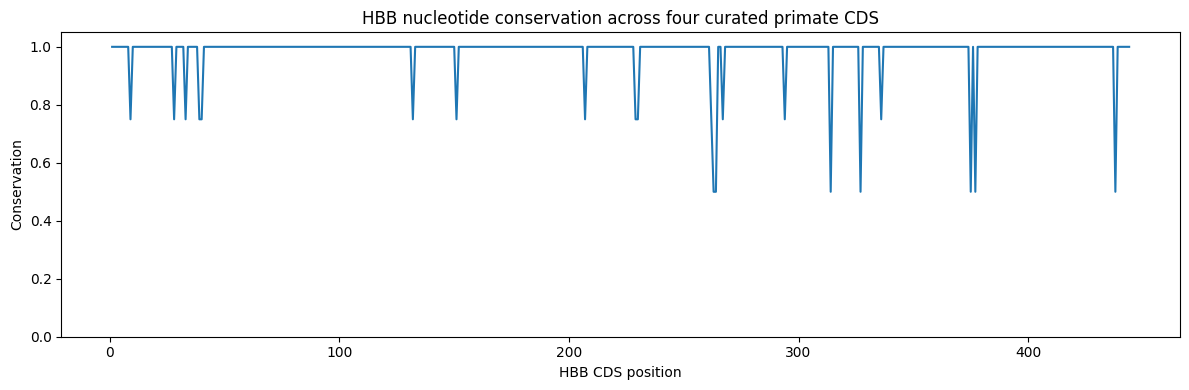

In [17]:
species_order = ["Human", "Gorilla", "Orangutan", "Rhesus macaque"]
alignment_length = len(core_cds["Human"])

conservation = []

for position in range(alignment_length):
    column = [core_cds[species][position] for species in species_order]
    conservation.append(
        pd.Series(column).value_counts().iloc[0] / len(column)
    )

conservation = np.array(conservation)

conservation_summary = pd.Series(conservation).value_counts().sort_index(ascending=False)
print("Conservation summary:")
display(
    conservation_summary.rename("Number_of_positions").to_frame()
)

plt.figure(figsize=(12, 4))
plt.plot(range(1, alignment_length + 1), conservation)
plt.ylim(0, 1.05)
plt.xlabel("HBB CDS position")
plt.ylabel("Conservation")
plt.title("HBB nucleotide conservation across four curated primate CDS")
plt.tight_layout()
plt.show()


# 12. What does the conservation plot tell us?

The plot is not just a figure; it answers part of the biological question.

If most positions remain near `1.0`, HBB is highly conserved across the four curated primates.

The small number of lower-conservation positions identifies locations where nucleotide substitutions have accumulated.

**Important interpretation:** high conservation is consistent with evolutionary constraint, but this plot alone does not prove a particular mechanism of natural selection.


# 13. Translate HBB into protein sequences

Nucleotide conservation and protein conservation are not identical.

Some nucleotide substitutions are **synonymous**, meaning the codon changes but the amino acid remains the same.

Therefore, we compare the translated HBB proteins separately.


In [18]:
proteins = {
    species: str(Seq(cds).translate(to_stop=True))
    for species, cds in core_cds.items()
}

protein_qc = pd.DataFrame([
    {
        "Species": species,
        "Protein_length_aa": len(protein),
        "Protein_sequence": protein,
    }
    for species, protein in proteins.items()
])

display(protein_qc)
print("✓ HBB protein sequences successfully translated.")


,Species,Protein_length_aa,Protein_sequence
0,Human,147,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...
1,Gorilla,147,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...
2,Orangutan,147,MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESF...
3,Rhesus macaque,147,MVHLTPEEKTAVTTLWGKVNVDEVGGEALGRLLVVYPWTQRFFDSF...


✓ HBB protein sequences successfully translated.


# 14. Protein identity relative to human HBB

Protein identity tells us how much of the HBB amino-acid sequence remains unchanged, which is directly relevant to conservation of the encoded protein.


In [19]:
human_protein = proteins["Human"]

protein_identity_rows = []

for species, protein in proteins.items():
    matches = sum(a == b for a, b in zip(human_protein, protein))

    protein_identity_rows.append({
        "Species": species,
        "Matching_amino_acids": matches,
        "Total_amino_acids": len(human_protein),
        "Protein_identity_to_Human_percent": round(
            100 * matches / len(human_protein), 3
        ),
    })

protein_identity = pd.DataFrame(protein_identity_rows)
display(protein_identity)

print("✓ Protein identity calculated.")


,Species,Matching_amino_acids,Total_amino_acids,Protein_identity_to_Human_percent
0,Human,147,147,100.000
1,Gorilla,146,147,99.320
2,Orangutan,145,147,98.639
3,Rhesus macaque,139,147,94.558


✓ Protein identity calculated.


# 15. Synonymous and non-synonymous differences

Each human-versus-primate nucleotide difference is examined at the codon level.

- **Synonymous:** nucleotide differs, amino acid stays the same.
- **Non-synonymous:** nucleotide differs and amino acid changes.

This gives a more biologically meaningful interpretation than nucleotide identity alone.


In [20]:
variant_rows = []

for species in ["Gorilla", "Orangutan", "Rhesus macaque"]:
    sequence = core_cds[species]

    for i in range(0, len(reference), 3):
        human_codon = reference[i:i+3]
        species_codon = sequence[i:i+3]

        if human_codon != species_codon:
            human_aa = str(Seq(human_codon).translate())
            species_aa = str(Seq(species_codon).translate())

            variant_rows.append({
                "Species": species,
                "Codon_position": i // 3 + 1,
                "Human_codon": human_codon,
                "Species_codon": species_codon,
                "Human_amino_acid": human_aa,
                "Species_amino_acid": species_aa,
                "Change_type": (
                    "Synonymous"
                    if human_aa == species_aa
                    else "Non-synonymous"
                ),
            })

variants = pd.DataFrame(variant_rows)

if variants.empty:
    print("No human-versus-primate CDS differences were detected.")
else:
    display(variants)
    print("\nSummary:")
    display(variants["Change_type"].value_counts().rename("Count").to_frame())


,Species,Codon_position,Human_codon,Species_codon,Human_amino_acid,Species_amino_acid,Change_type
0,Gorilla,105,AGG,AAG,R,K,Non-synonymous
1,Gorilla,109,AAC,AAT,N,N,Synonymous
2,Orangutan,11,GCC,GCT,A,A,Synonymous
3,Orangutan,88,ACA,AAG,T,K,Non-synonymous
4,Orangutan,109,AAC,AAT,N,N,Synonymous
5,Orangutan,125,CCA,CCG,P,P,Synonymous
6,Orangutan,126,CCA,CAA,P,Q,Non-synonymous
7,Orangutan,146,TAT,TAC,Y,Y,Synonymous
8,Rhesus macaque,3,CAC,CAT,H,H,Synonymous
9,Rhesus macaque,10,TCT,ACT,S,T,Non-synonymous



Summary:


,Count
Change_type,
Synonymous,13
Non-synonymous,11


# 16. Main biological results

The notebook now has four layers of evidence:

### A. Nucleotide identity
Shows how similar each primate HBB CDS is to human HBB.

### B. Conservation profile
Shows which individual CDS positions are conserved or variable.

### C. Protein identity
Shows whether nucleotide changes actually alter the HBB amino-acid sequence.

### D. Synonymous/non-synonymous analysis
Shows whether observed coding differences are silent or change the encoded protein.

Together, these analyses provide a stronger biological interpretation than a single percentage identity.


In [21]:
print("========== PROJECT RESULT SUMMARY ==========")

print("\nNucleotide identity to human HBB:")
for _, row in nucleotide_identity.iterrows():
    print(
        f"  {row['Species']:18s}: "
        f"{row['Nucleotide_identity_to_Human_percent']:.2f}%"
    )

print("\nProtein identity to human HBB:")
for _, row in protein_identity.iterrows():
    print(
        f"  {row['Species']:18s}: "
        f"{row['Protein_identity_to_Human_percent']:.2f}%"
    )

print("\nNucleotide conservation:")
print(f"  Fully conserved positions: {int(sum(conservation == 1.0))}/{len(conservation)}")
print(f"  75% conserved positions:   {int(sum(conservation == 0.75))}/{len(conservation)}")
print(f"  50% conserved positions:   {int(sum(conservation == 0.50))}/{len(conservation)}")

if not variants.empty:
    print("\nHuman-versus-primate coding differences:")
    print(variants["Change_type"].value_counts().to_string())

print("\nOverall interpretation:")
print(
    "HBB is highly conserved across the four curated primate CDS records. "
    "This pattern is consistent with evolutionary constraint, but conservation "
    "alone does not prove a specific selection mechanism."
)


========== PROJECT RESULT SUMMARY ==========

Nucleotide identity to human HBB:
  Human             : 100.00%
  Gorilla           : 99.55%
  Orangutan         : 98.42%
  Rhesus macaque    : 95.72%

Protein identity to human HBB:
  Human             : 100.00%
  Gorilla           : 99.32%
  Orangutan         : 98.64%
  Rhesus macaque    : 94.56%

Nucleotide conservation:
  Fully conserved positions: 423/444
  75% conserved positions:   14/444
  50% conserved positions:   7/444

Human-versus-primate coding differences:
Change_type
Synonymous        13
Non-synonymous    11

Overall interpretation:
HBB is highly conserved across the four curated primate CDS records. This pattern is consistent with evolutionary constraint, but conservation alone does not prove a specific selection mechanism.


# 17. Biological interpretation

## What is the project actually asking?

The project asks whether an essential hemoglobin gene remains highly conserved during primate evolution.

If HBB performs an important and constrained biological function, we expect harmful changes to be less likely to persist, producing a generally conserved sequence.

## What do our results support?

The high nucleotide and protein similarity observed among the curated primate HBB sequences is **consistent with strong evolutionary constraint**.

The pattern also broadly follows the expectation that more closely related primates should have more similar HBB sequences.

## What do the results NOT prove?

This project does not, by itself, prove:

- positive selection;
- negative/purifying selection by a formal statistical test;
- adaptation;
- disease causation;
- pathogenicity of an individual variant;
- or a complete species phylogeny.

Those claims would require additional analyses and/or external biological evidence.


# 19. Limitations and next steps

### Current limitations

1. Only a small number of primate species are included.
2. The chimpanzee record supplied for this project is partial/genomic and therefore requires annotation-based CDS extraction before full inclusion.
3. The direct CDS comparison assumes that the curated four sequences represent the same homologous coding region.
4. Conservation alone is not a formal test of selection.

### Professional next steps

A future expanded version could:

- retrieve the exact annotated chimpanzee CDS;
- include additional primates;
- perform a formal multiple sequence alignment;
- construct an HBB gene tree;
- calculate dN/dS with an appropriate evolutionary model;
- compare conserved sites with known HBB functional regions.


# 20. Final conclusion

## Answer to the biological question

Using the **four curated complete HBB CDS records** in this notebook, the observed nucleotide identity relative to human HBB is:

- **Human:** 100.00%
- **Gorilla:** 99.55%
- **Orangutan:** 98.42%
- **Rhesus macaque:** 95.72%

At the protein level, the corresponding identity values are:

- **Human:** 100.00%
- **Gorilla:** 99.32%
- **Orangutan:** 98.64%
- **Rhesus macaque:** 94.56%

Across the 444-nt curated CDS comparison, **423 positions were completely conserved**, 14 positions had 75% conservation, and 7 positions had 50% conservation. The human-versus-primate coding comparison identified **24 codon-level differences: 13 synonymous and 11 non-synonymous**.

### Biological interpretation

The HBB coding sequence is highly conserved across the sampled primates, while the degree of similarity decreases with the more evolutionarily distant rhesus macaque sequence in this small dataset. The high nucleotide and amino-acid conservation is **consistent with strong evolutionary constraint on an essential hemoglobin gene**.

### Important limitation

The chimpanzee record is retained for QC but is **not included in these four-species quantitative CDS results** because the supplied record is a partial genomic sequence. It should not be forced into the complete-CDS analysis without confirming its annotated CDS coordinates.

This project therefore supports the conclusion that **HBB is highly conserved across the curated primate CDS set**, but it does **not** by itself prove a particular selection mechanism, adaptation, pathogenicity, or clinical significance.